In [15]:
import os
import json
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("라이브러리 로드 완료!")

라이브러리 로드 완료!


In [16]:
# klec txt 파일 전체 읽기
txt_files = glob.glob('../data/klec/**/*.txt', recursive=True)
print(f"총 txt 파일 수: {len(txt_files)}")

# 파일 몇 개 내용 확인
for f in txt_files[:3]:
    with open(f, 'r', encoding='utf-8') as file:
        content = file.read().strip()
    print(f"\n파일: {os.path.basename(f)}")
    print(f"내용: {content}")

총 txt 파일 수: 296820

파일: 000000.txt
내용: n/ 어디갔지? 우리 반 우리교실

파일: 000001.txt
내용: n/ 아/ 큰일 났다, 우리교실 어디있지?

파일: 000002.txt
내용: n/ 어 허 우리교실


In [17]:
# 필러워드 태그 정의
FILLER_TAGS = ['아/', '어/', '음/', '그/', '뭐/', '저/', '이/', 'n/']

def extract_features(text):
    words = text.strip().split()
    total = len(words)
    if total == 0:
        return None
    
    # 필러워드 수
    filler_count = sum(1 for w in words if any(w.startswith(tag) or w == tag[:-1] for tag in FILLER_TAGS))
    
    # 순수 텍스트 (태그 제거)
    clean_words = [re.sub(r'[a-z]/', '', w) for w in words]
    clean_words = [w for w in clean_words if w.strip()]
    
    # 어휘 다양성
    vocab_diversity = len(set(clean_words)) / len(clean_words) if clean_words else 0
    
    # 평균 단어 길이
    avg_word_len = np.mean([len(w) for w in clean_words]) if clean_words else 0
    
    return {
        'total_words': total,
        'filler_count': filler_count,
        'filler_ratio': filler_count / total,
        'vocab_diversity': vocab_diversity,
        'avg_word_len': avg_word_len,
        'text': text.strip()
    }

# 테스트
sample_text = "n/ 아/ 큰일 났다, 우리교실 어디있지?"
print(extract_features(sample_text))

{'total_words': 6, 'filler_count': 2, 'filler_ratio': 0.3333333333333333, 'vocab_diversity': 1.0, 'avg_word_len': np.float64(3.2), 'text': 'n/ 아/ 큰일 났다, 우리교실 어디있지?'}


In [18]:
# 전체 txt 파일에서 feature 추출 (샘플 5000개만)
import random
random.seed(42)

sampled_files = random.sample(txt_files, min(5000, len(txt_files)))
print(f"샘플 파일 수: {len(sampled_files)}")

records = []
for filepath in sampled_files:
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            text = f.read().strip()
        
        if len(text) < 2:  # 너무 짧은 텍스트 제외
            continue
            
        features = extract_features(text)
        if features:
            records.append(features)
    except:
        continue

df = pd.DataFrame(records)
print(f"\n추출 완료! 총 {len(df)}개")
print(df.describe())

샘플 파일 수: 5000

추출 완료! 총 5000개
       total_words  filler_count  filler_ratio  vocab_diversity  avg_word_len
count  5000.000000   5000.000000   5000.000000      5000.000000   5000.000000
mean     12.372200      0.565400      0.056394         0.965410      3.562169
std       8.416165      0.804644      0.094018         0.068567      1.135422
min       1.000000      0.000000      0.000000         0.289474      1.000000
25%       6.000000      0.000000      0.000000         0.947368      2.900000
50%      10.000000      0.000000      0.000000         1.000000      3.300000
75%      17.000000      1.000000      0.083929         1.000000      3.909091
max      50.000000      8.000000      1.000000         1.000000     15.000000


=== 레이블 분포 ===
label
1    4524
0     476
Name: count, dtype: int64

Good 비율: 90.5%
Poor 비율: 9.5%


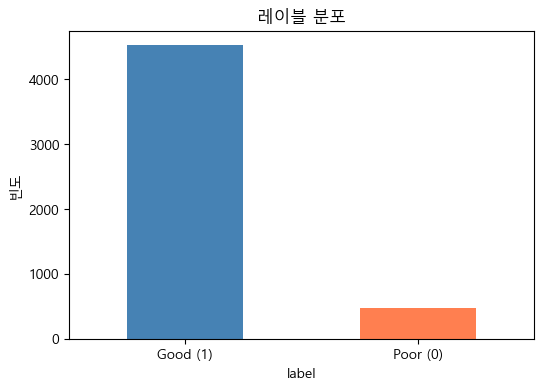

그래프 저장 완료!


In [19]:
# 레이블 기준 (EDA에서 확인한 값 기반)
# 필러워드 비율 > 17% → Poor (0)
# 필러워드 비율 <= 17% → Good (1)

df['label'] = (df['filler_ratio'] <= 0.17).astype(int)

print("=== 레이블 분포 ===")
print(df['label'].value_counts())
print(f"\nGood 비율: {df['label'].mean()*100:.1f}%")
print(f"Poor 비율: {(1-df['label'].mean())*100:.1f}%")

# 레이블 분포 시각화
plt.figure(figsize=(6,4))
df['label'].value_counts().plot(kind='bar', color=['steelblue', 'coral'])
plt.xticks([0, 1], ['Good (1)', 'Poor (0)'], rotation=0)
plt.title('레이블 분포')
plt.ylabel('빈도')
plt.savefig('../results/label_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("그래프 저장 완료!")

In [20]:
# 기준 조정 — 중앙값(8%) 기준으로 나누기
df['label'] = (df['filler_ratio'] <= df['filler_ratio'].median()).astype(int)

print("=== 조정된 레이블 분포 ===")
print(df['label'].value_counts())
print(f"\nGood 비율: {df['label'].mean()*100:.1f}%")
print(f"Poor 비율: {(1-df['label'].mean())*100:.1f}%")

=== 조정된 레이블 분포 ===
label
1    2874
0    2126
Name: count, dtype: int64

Good 비율: 57.5%
Poor 비율: 42.5%


In [21]:
# feature 컬럼만 선택
feature_cols = ['total_words', 'filler_count', 'filler_ratio', 
                'vocab_diversity', 'avg_word_len']

X = df[feature_cols]
y = df['label']

# Train/Test 분리 (8:2)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Train/Val 분리 (Train의 8:2 → 전체 7:1:2)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.125, random_state=42, stratify=y_train)

print(f"Train: {len(X_train)}개")
print(f"Val:   {len(X_val)}개")
print(f"Test:  {len(X_test)}개")

# CSV 저장
train_df = X_train.copy()
train_df['label'] = y_train
val_df = X_val.copy()
val_df['label'] = y_val
test_df = X_test.copy()
test_df['label'] = y_test

train_df.to_csv('../data/train.csv', index=False)
val_df.to_csv('../data/val.csv', index=False)
test_df.to_csv('../data/test.csv', index=False)

print("\nCSV 저장 완료!")
print(f"Train label 분포:\n{y_train.value_counts()}")

Train: 3500개
Val:   500개
Test:  1000개

CSV 저장 완료!
Train label 분포:
label
1    2012
0    1488
Name: count, dtype: int64
